# Supplementary Figure S5 — Active-zone [Ca$^{2+}$] variability over a sustained train

CV of [Ca$^{2+}$]$_{AZ}$ across a 20-pulse, 20 Hz train, control vs. AD + 5x RyR. Companion to Fig. 10 (main text): confirms the growing release unreliability seen there is not driven by increased variability in the calcium signal itself.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# plot_config.py lives in the same figures/ directory
sys.path.insert(0, str(Path(".").resolve()))
from plot_config import (
    get_condition,
    apply_style,
    strip_spines,
    label_panel,
    save_figure,
)

apply_style()

In [2]:
# ============================================================
# CONFIG
# ============================================================

CONTROL_RESULT = Path(
    "/data/hdrive/phd/results/train/control/RSV90C250uM_20_p20hz/result"
)
AD_RESULT = Path(
    "/data/hdrive/phd/results/train/AD/RSV90C750uM_20_p20hz_5xryr/result"
)

RESULTS_ROOT = Path("/data/hdrive/phd/results/train")
TRIALS_ROOT = Path("/data/hdrive/phd/output/train")


def trials_dir_for(result_file: Path) -> Path:
    """Map a `.../results/train/<condition>/result` summary file to its
    per-trial sibling directory under `.../output/train/<condition>/`
    (one s_NNNNN/dat/ca.dat per trial)."""
    return TRIALS_ROOT / result_file.parent.relative_to(RESULTS_ROOT)


CONDITION_TRIALS = {
    "control": trials_dir_for(CONTROL_RESULT),
    "ad_5x_ryr": trials_dir_for(AD_RESULT),
}
CONDITION_ORDER = ["control", "ad_5x_ryr"]  # draw order == legend order

# 20-pulse, 20 Hz train.
N_PULSES = 20
PULSE_PERIOD = 0.05  # s (20 Hz)

AZCV_SMOOTH_WINDOW_TRAIN = 21  # samples (~1.05 ms at the 50 us native step)

FIGSIZE = (5, 3.5)
SAVE_NAME = "figS5_train_calcium_CV.png"

In [3]:
# ============================================================
# DATA LOADING
# ============================================================

def compute_ca_conc(time, ca, step=5):
    """Exact modFuncNew.py computeCaConc: t*ca, step-windowed finite difference."""
    c_tc = time * ca
    dt = step * (time[1] - time[0])
    n = (len(time) - step - 1) // step
    idx = np.arange(0, n * step, step)
    return time[idx], (c_tc[idx + step] - c_tc[idx]) / dt


def load_az_cv_over_time_train(trials_dir, step=5):
    trial_dirs = sorted(p for p in trials_dir.iterdir() if p.name.startswith("s_"))
    t_ref = None
    traces = []
    min_duration = 0.99 * N_PULSES * PULSE_PERIOD  # exclude crashed/truncated runs
    for d in trial_dirs:
        fpath = d / "dat" / "ca.dat"
        if not fpath.exists() or fpath.stat().st_size == 0:
            continue  # failed trial, e.g. crashed sim run
        t, az_raw = np.loadtxt(fpath, usecols=(0, 1), unpack=True, skiprows=1)
        if len(t) == 0 or t[-1] < min_duration:
            continue
        t_az, az_conc = compute_ca_conc(t, az_raw, step)
        if t_ref is None:
            t_ref = t_az
        if len(az_conc) == len(t_ref):
            traces.append(az_conc)
    traces = np.array(traces)
    mean_t = traces.mean(axis=0)
    std_t = traces.std(axis=0, ddof=1)
    cv_t = np.divide(std_t, mean_t, out=np.full_like(mean_t, np.nan), where=mean_t != 0)
    return t_ref, mean_t, cv_t, len(traces)


def _smooth(y, window):
    if window <= 1:
        return y
    kernel = np.ones(window) / window
    return np.convolve(y, kernel, mode="same")


train_az_cv = {}
for key in CONDITION_ORDER:
    t_ref, mean_t, cv_t, n_used = load_az_cv_over_time_train(CONDITION_TRIALS[key])
    train_az_cv[key] = {"time": t_ref, "mean": mean_t, "cv": cv_t}
    print(f"{key:12s}  {n_used} trials used for AZ CV(t)")

control       2004 trials used for AZ CV(t)


ad_5x_ryr     2005 trials used for AZ CV(t)


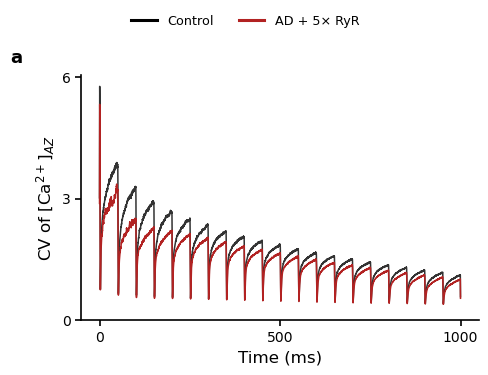

In [4]:
# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE)

for key in CONDITION_ORDER:
    cond = get_condition(key)
    d = train_az_cv[key]
    cv_smooth = _smooth(d["cv"], AZCV_SMOOTH_WINDOW_TRAIN)
    ax.plot(d["time"] * 1000.0, cv_smooth, color=cond.color, linewidth=1.1,
            alpha=cond.alpha, zorder=cond.zorder, label=cond.label)

ax.set_xlabel("Time (ms)")
ax.set_ylabel(r"CV of [Ca$^{2+}$]$_{AZ}$")
ax.set_xticks([0, 500, 1000])
ax.set_yticks([0, 3, 6])
strip_spines(ax)
label_panel(ax, "a")

condition_handles = [
    Line2D([0], [0], color=get_condition(k).color, label=get_condition(k).label)
    for k in CONDITION_ORDER
]
fig.legend(handles=condition_handles, loc="upper center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.08), fontsize="small")

plt.tight_layout()
save_figure(fig, SAVE_NAME)
plt.show()